*Contents of this notebook*: this notebook contains a portion of the downstream analysis performed in the integrated dataset (WT, partial and full HOX KO). We wanted to compare the DEG across clusters but to account for differences in size, we performed a subsampling.  

### Load annotated dataset (Integrated) 



In [1]:
import os

In [2]:
!conda info --envs

# conda environments:
#
base                     C:\Users\aleja\anaconda3
singlecellEnv            C:\Users\aleja\anaconda3\envs\singlecellEnv
textenv               *  C:\Users\aleja\anaconda3\envs\textenv



In [3]:
os. getcwd() 

'D:\\BIOINFO\\POURQUIE\\HOX_project\\Analysis_SCANPY'

In [4]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
sc.settings.verbosity = 3             
sc.logging.print_versions()  #updated scanpy to 1.10
sc.settings.set_figure_params(dpi=80, facecolor='white')

-----
anndata     0.10.7
scanpy      1.10.0
-----
PIL                         8.4.0
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        23.2.0
attrs                       23.2.0
babel                       2.14.0
backcall                    0.2.0
bottleneck                  1.3.7
brotli                      NA
certifi                     2024.08.30
cffi                        1.16.0
chardet                     5.2.0
charset_normalizer          3.3.2
cloudpickle                 3.0.0
colorama                    0.4.6
comm                        0.2.1
cycler                      0.12.1
cython_runtime              NA
cytoolz                     0.12.3
dask                        2024.2.0
dateutil                    2.8.2
debugpy                     1.8.1
decorator                   5.1.1
defusedxml                  0.7.1
exceptiongroup              1.2.0
executing                   2.0.1
fastjsonschema              NA

In [6]:
adata = sc.read_h5ad("H5AD/20241113_HOXsamples_all_qc_filtered_dr_Harmony_clustered_anno.h5ad")

In [7]:
adata_subset = adata[adata.obs['annotation'].isin(['NMP', 'pPSM','aPSM',"Somite_1",
                     'Somite_2', 'Head_Mesoderm'])].copy() # we subset the most relevant clusters for further analysis 

In [8]:
adata_subset.obs['annotation_short'] = (
    adata_subset.obs["annotation"]
    .map(lambda x: {"Somite_1": "Somite", "Somite_2": "Somite"}.get(x, x))
    .astype("category")
)

In [9]:
adata_subset.obs['annotation_short'] = adata_subset.obs['annotation_short'].cat.reorder_categories(['NMP','pPSM','aPSM','Somite',
                     'Head_Mesoderm'])

In [10]:
# As we only intend to do DEG comparing HOX_KO vs WT, let's substract them:
samples_of_interest = ['WT', 'HOX_KO']

# Create a new AnnData object with only the two samples and only the PSM-related clusters
adata_WT_HOXKO_subset = adata_subset[adata_subset.obs['sample'].isin(samples_of_interest)].copy()

C:\Users\aleja\AppData\Local\Temp\ipykernel_23516\849130462.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = adata_WT_HOXKO_subset.obs.groupby(['annotation_short', 'sample']).size().unstack()


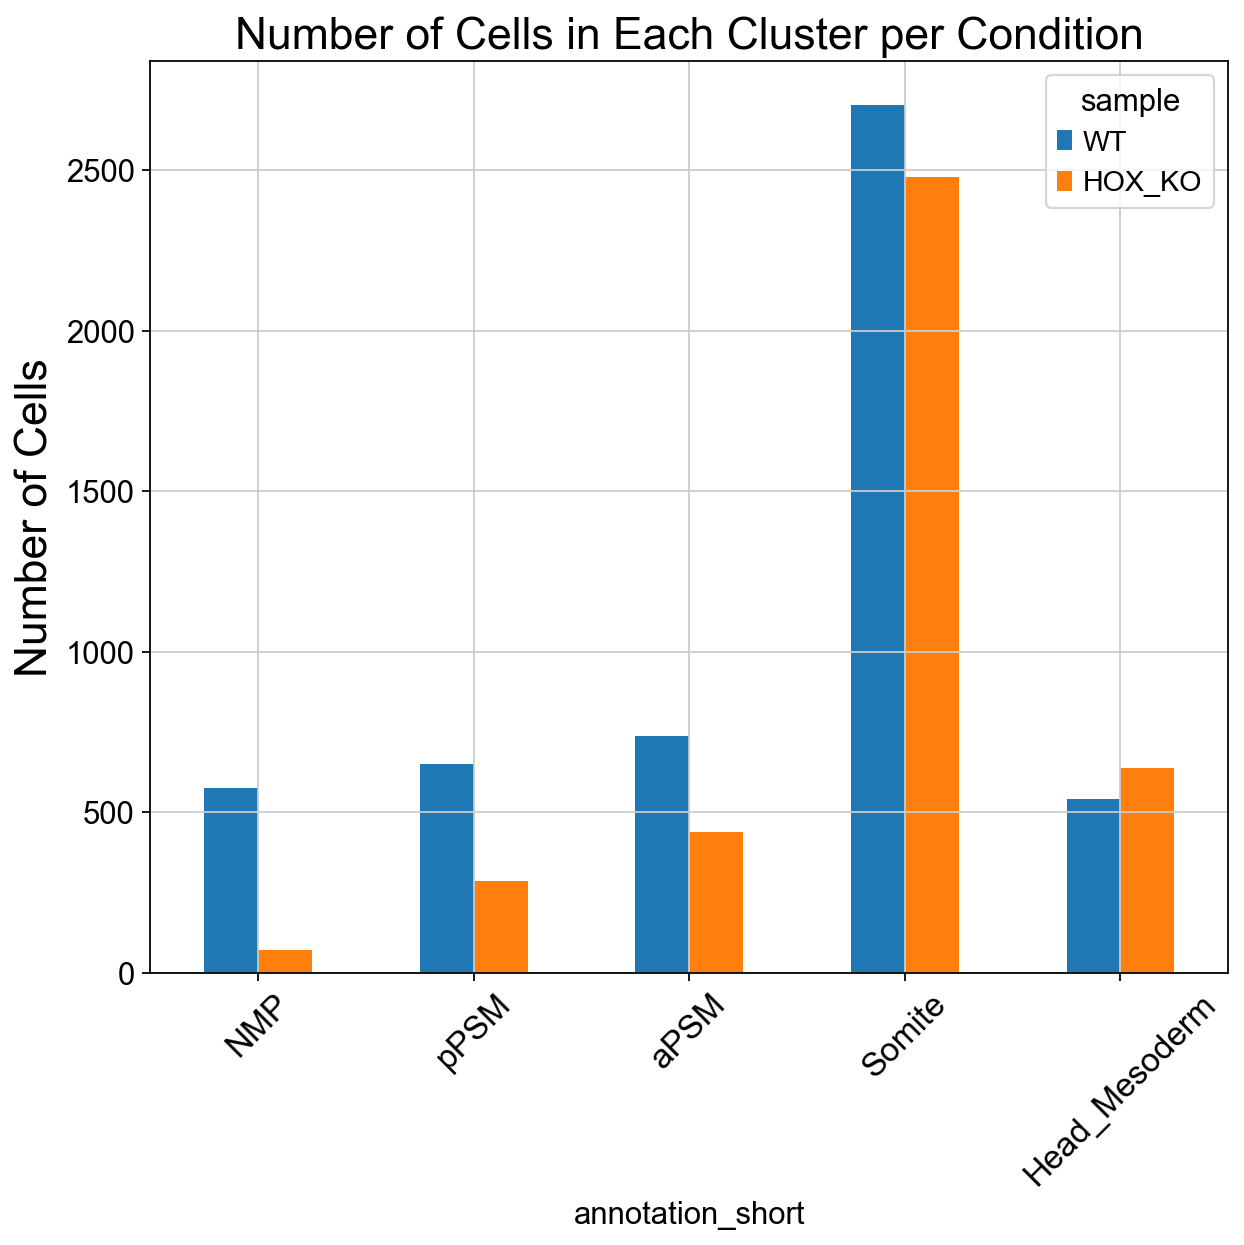

In [11]:

# Count the number of cells per cluster per condition
cell_counts = adata_WT_HOXKO_subset.obs.groupby(['annotation_short', 'sample']).size().unstack()

# Define the desired order of conditions (samples)
desired_order = ['WT', 'HOX_KO']  # Adjust this to your condition names

# Reorder the columns based on the desired order
cell_counts = cell_counts.reindex(columns=desired_order)

# Plotting the number of cells per cluster for each condition
cell_counts.plot(kind='bar', stacked=False, figsize=(8, 8))
plt.ylabel('Number of Cells', size=20)
plt.title('Number of Cells in Each Cluster per Condition', size=20)
plt.xticks(rotation=45, size=15)
plt.tight_layout()

# Save the plot to a PDF file with 300 DPI resolution
plt.savefig('figures/SUBSAMPLING/20241202_HOXKOvsWT_cells_per_cluster_per_condition.pdf', format='pdf', dpi=300)

# Show the plot
plt.show()


## Subsampling to the smaller cluster

In [12]:
adata_WT_HOXKO_subset.obs['annotation_short'].value_counts()  # NMP is the smallest cluster with 644 cells, let's make all clusters 644 cells

annotation_short
Somite           5183
Head_Mesoderm    1180
aPSM             1175
pPSM              938
NMP               644
Name: count, dtype: int64

In [13]:
clusters = adata_WT_HOXKO_subset.obs['annotation_short'].unique()

# Set a desired subsample size (the minimum cluster size)
min_cluster_size = min([sum(adata_WT_HOXKO_subset.obs['annotation_short'] == cl) for cl in clusters])

In [14]:

# Define your target number of cells to subsample per cluster
target_cells = min_cluster_size 

# Create an empty list to store the subsampled AnnData objects
adata_subsampled_list = []

# Loop through each cluster and subsample
for cluster in adata_WT_HOXKO_subset.obs['annotation_short'].unique():
    # Select cells belonging to the current cluster
    adata_cluster = adata_WT_HOXKO_subset[adata_WT_HOXKO_subset.obs['annotation_short'] == cluster].copy()
    
    # Subsample the cluster to 'target_cells'
    sc.pp.subsample(adata_cluster, n_obs=target_cells)
    
    # Store the subsampled cluster data
    adata_subsampled_list.append(adata_cluster)

# Concatenate all subsampled clusters into one AnnData object
adata_subsampled = adata_subsampled_list[0].concatenate(adata_subsampled_list[1:])

# Now you have a dataset with uniform subsample sizes for each cluster
print(adata_subsampled)


C:\Users\aleja\AppData\Local\Temp\ipykernel_23516\4160511279.py:19: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_subsampled = adata_subsampled_list[0].concatenate(adata_subsampled_list[1:])


AnnData object with n_obs × n_vars = 3220 × 30520
    obs: 'sample', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden_0.1', 'leiden_0.2', 'leiden_0.25', 'leiden_0.3', 'annotation', 'annotation_short'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    obsm: 'X_pca', 'X_pca_harmony', 'X_tsne', 'X_umap'


In [15]:
adata_subsampled.obs['annotation_short'].value_counts()

annotation_short
Head_Mesoderm    644
NMP              644
Somite           644
aPSM             644
pPSM             644
Name: count, dtype: int64

In [16]:
NMP = adata_subsampled[adata_subsampled.obs['annotation_short'] == 'NMP',:].copy()
pPSM = adata_subsampled[adata_subsampled.obs['annotation_short'] == 'pPSM',:].copy()
aPSM = adata_subsampled[adata_subsampled.obs['annotation_short'] == 'aPSM',:].copy()
Somite = adata_subsampled[adata_subsampled.obs['annotation_short'] == 'Somite',:].copy()
Head_Mesoderm = adata_subsampled[adata_subsampled.obs['annotation_short'] == 'Head_Mesoderm',:].copy()


## NMP

In [17]:
NMP.obs['sample'].value_counts()

sample
WT        574
HOX_KO     70
Name: count, dtype: int64

ranking genes
    finished: added to `.uns['DEG_subsampled']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


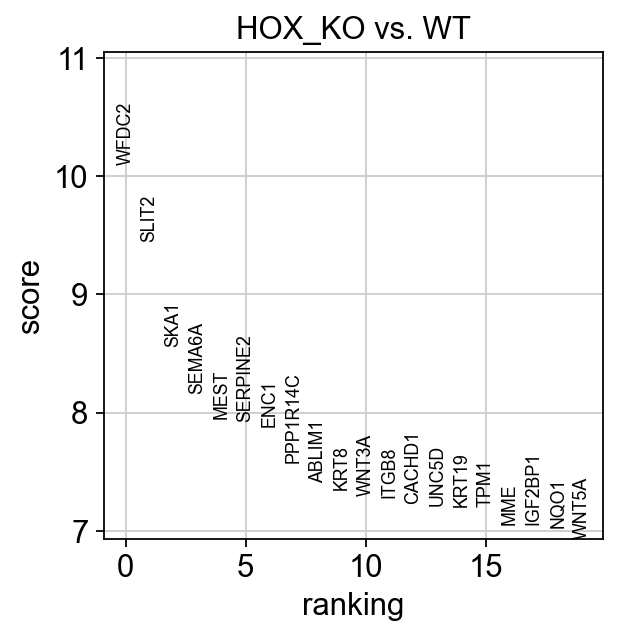

In [18]:
sc.tl.rank_genes_groups(NMP, 'sample', reference="WT",method='wilcoxon', key_added = "DEG_subsampled")
sc.pl.rank_genes_groups(NMP, n_genes=20, sharey=False, key="DEG_subsampled")

In [19]:
def rank_genes_groups_df(adata, group, pval_cutoff : float =0.05, logfc_cutoff=0.58): 
    d = pd.DataFrame() 
    for k in ['scores', 'names', 'logfoldchanges', 'pvals', 'pvals_adj']: 
        d[k] = adata.uns["DEG_subsampled"][k][group] 
    if pval_cutoff is not None: 
        d = d[d["pvals_adj"] <= pval_cutoff] 
    if logfc_cutoff is not None: 
        d = d[d["logfoldchanges"].abs() >= logfc_cutoff] 
    return d

In [20]:
NMP_df = rank_genes_groups_df(NMP,"HOX_KO")  

## PSM

In [21]:
pPSM.obs['sample'].value_counts()

sample
WT        456
HOX_KO    188
Name: count, dtype: int64

ranking genes
    finished: added to `.uns['DEG_subsampled']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


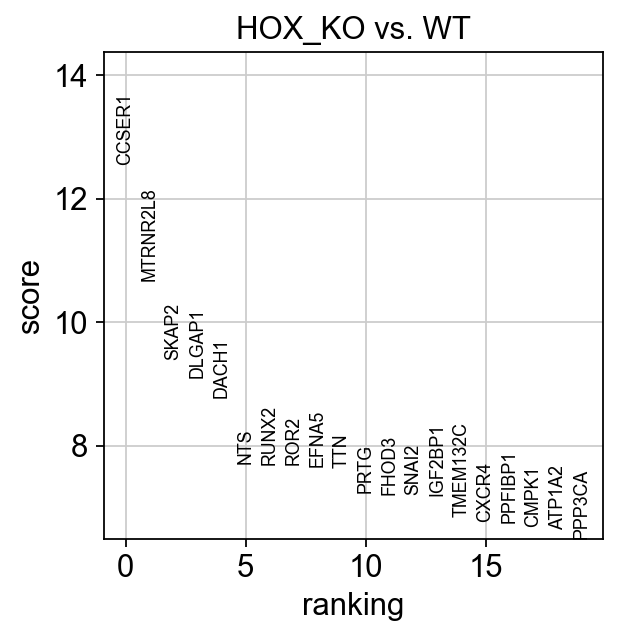

In [22]:
sc.tl.rank_genes_groups(pPSM, 'sample', reference="WT",method='wilcoxon', key_added = "DEG_subsampled")
sc.pl.rank_genes_groups(pPSM, n_genes=20, sharey=False, key="DEG_subsampled")

In [23]:
pPSM_df = rank_genes_groups_df(pPSM,"HOX_KO")

## anterior PSM

In [24]:
aPSM.obs['sample'].value_counts()

sample
WT        399
HOX_KO    245
Name: count, dtype: int64

ranking genes
    finished: added to `.uns['DEG_subsampled']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


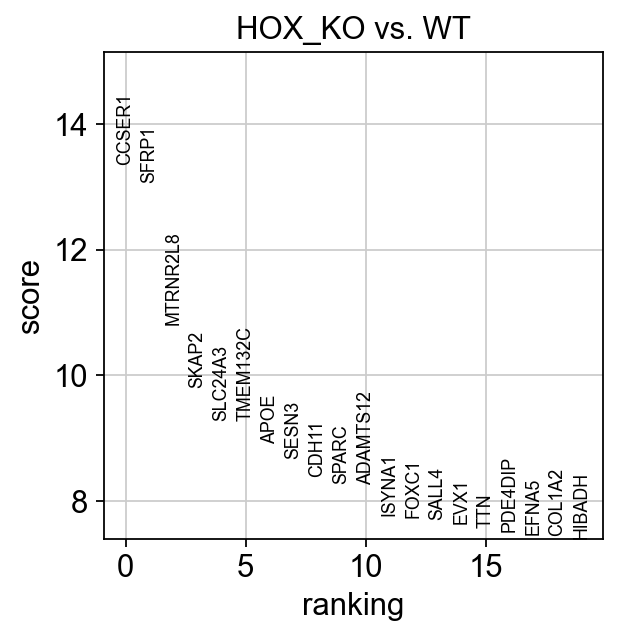

In [25]:
sc.tl.rank_genes_groups(aPSM, 'sample', reference="WT",method='wilcoxon', key_added = "DEG_subsampled")
sc.pl.rank_genes_groups(aPSM, n_genes=20, sharey=False, key="DEG_subsampled")

In [26]:
aPSM_df = rank_genes_groups_df(aPSM,"HOX_KO")

## Somite

In [27]:
Somite.obs['sample'].value_counts()

sample
WT        339
HOX_KO    305
Name: count, dtype: int64

ranking genes
    finished: added to `.uns['DEG_subsampled']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


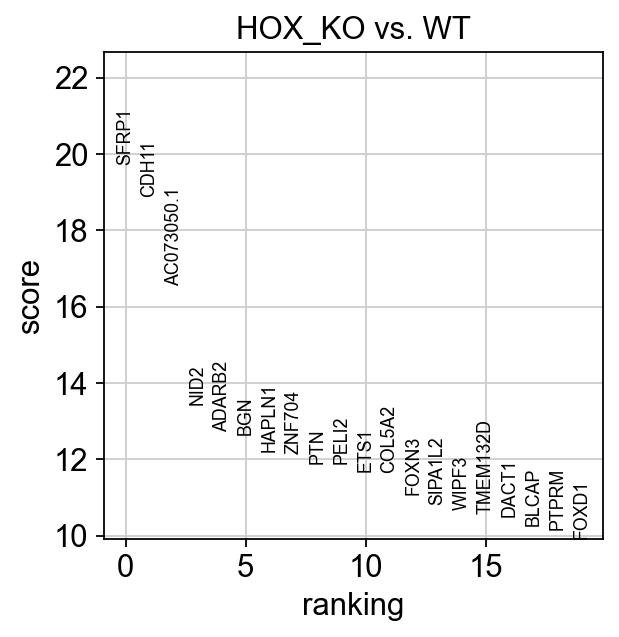

In [28]:
sc.tl.rank_genes_groups(Somite, 'sample', reference="WT",method='wilcoxon', key_added = "DEG_subsampled")
sc.pl.rank_genes_groups(Somite, n_genes=20, sharey=False, key="DEG_subsampled")

In [29]:
Somite_df = rank_genes_groups_df(Somite,"HOX_KO")

## Head Mesoderm

In [30]:
Head_Mesoderm.obs['sample'].value_counts()

sample
HOX_KO    357
WT        287
Name: count, dtype: int64

ranking genes
    finished: added to `.uns['DEG_subsampled']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


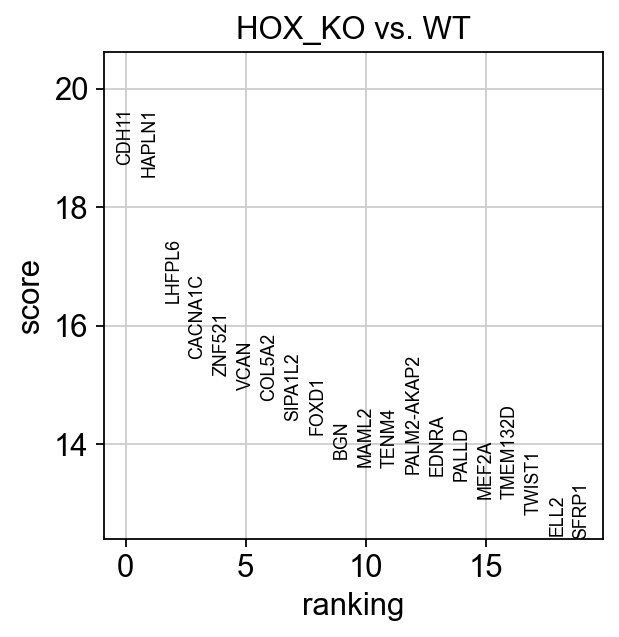

In [31]:
sc.tl.rank_genes_groups(Head_Mesoderm, 'sample', reference="WT",method='wilcoxon', key_added = "DEG_subsampled")
sc.pl.rank_genes_groups(Head_Mesoderm, n_genes=20, sharey=False, key="DEG_subsampled")

In [32]:
Head_Mesoderm_df = rank_genes_groups_df(Head_Mesoderm,"HOX_KO")

## Summary of the parsed DEG

In [33]:
print(f"Number of rows in NMP_df: {NMP_df.shape[0]}")
print(f"Number of rows in pPSM_df: {pPSM_df.shape[0]}")
print(f"Number of rows in aPSM_df: {aPSM_df.shape[0]}")
print(f"Number of rows in Somite_df: {Somite_df.shape[0]}")
print(f"Number of rows in Head_Mesoderm_df: {Head_Mesoderm_df.shape[0]}")

Number of rows in NMP_df: 246
Number of rows in pPSM_df: 198
Number of rows in aPSM_df: 412
Number of rows in Somite_df: 700
Number of rows in Head_Mesoderm_df: 1076


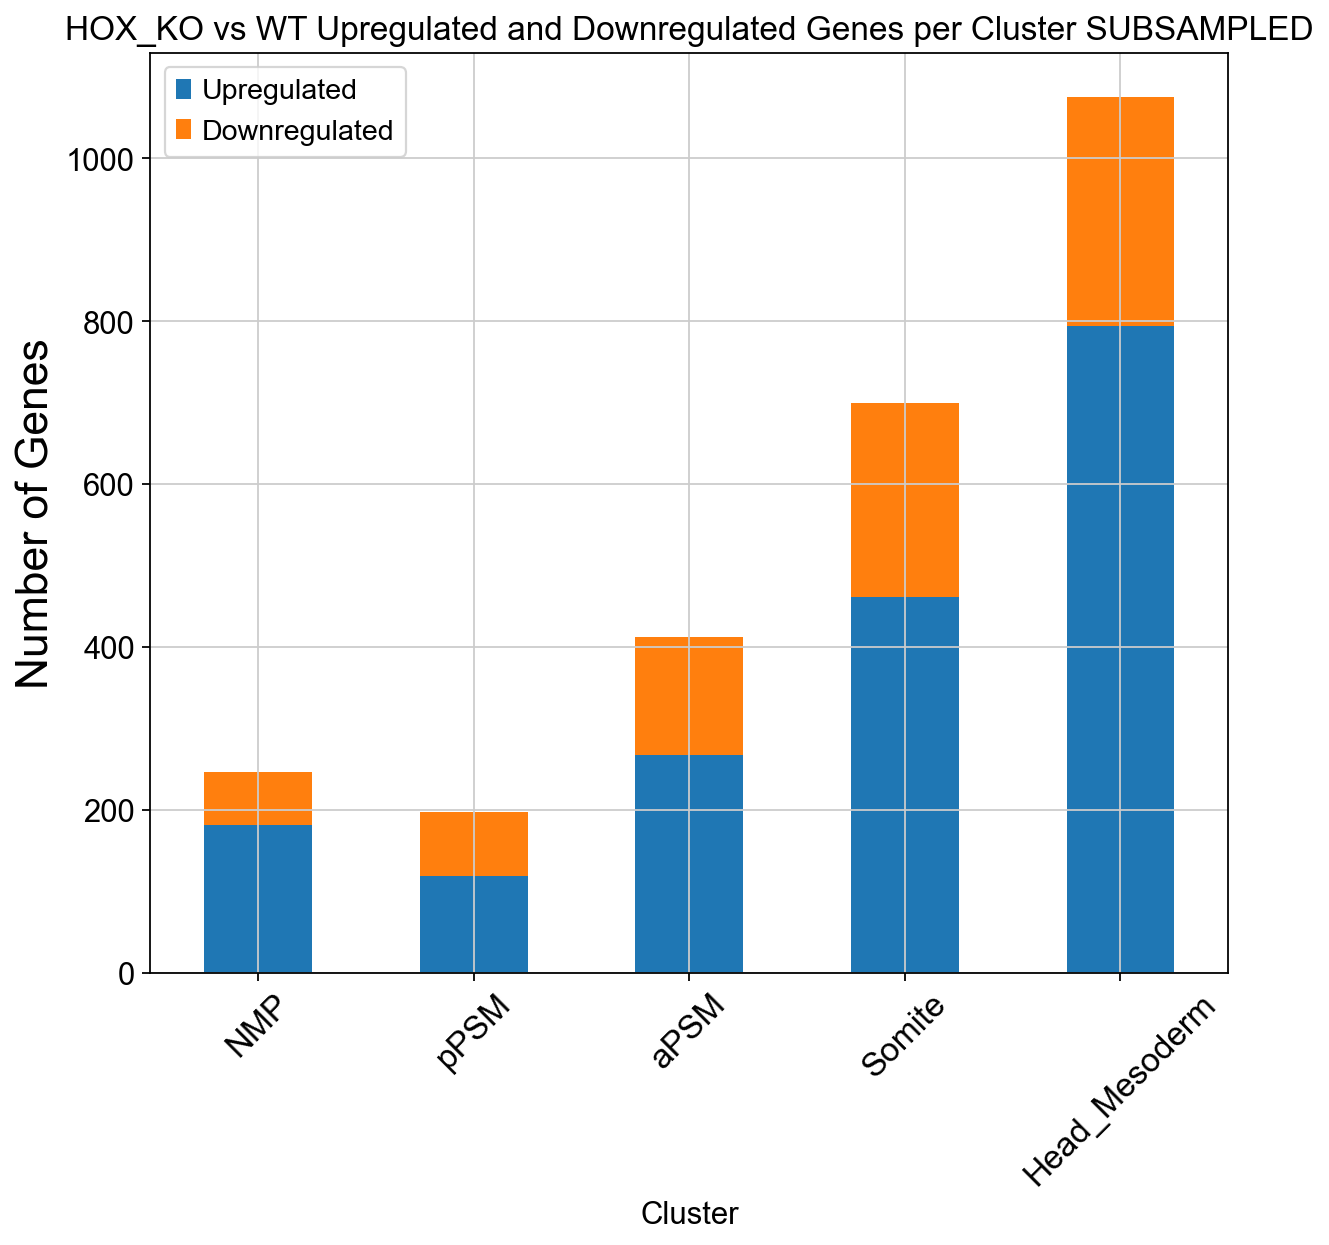

In [34]:
# Assume you have a dictionary where keys are cluster names and values are dataframes
# Each dataframe has filtered genes for absolute logfoldchange and adjusted p-values
deg_data = {
    'NMP': NMP_df,  # Replace with actual dataframes
    'pPSM': pPSM_df,
    'aPSM': aPSM_df,
    'Somite': Somite_df,
    'Head_Mesoderm': Head_Mesoderm_df,
}

# Initialize empty lists to store counts for each cluster
upregulated_counts = []
downregulated_counts = []
clusters = deg_data.keys()

# Define thresholds for counting upregulated and downregulated genes
logfc_threshold = 0.58  

# Loop through each cluster's dataframe
for cluster in clusters:
    # Get the dataframe for the current cluster
    df = deg_data[cluster]
    
    # Count upregulated and downregulated genes
    upregulated = df[df['logfoldchanges'] > logfc_threshold]
    downregulated = df[df['logfoldchanges'] < -logfc_threshold]
    
    upregulated_counts.append(len(upregulated))
    downregulated_counts.append(len(downregulated))

# Create a DataFrame for plotting
df_counts = pd.DataFrame({
    'Cluster': clusters,
    'Upregulated': upregulated_counts,
    'Downregulated': downregulated_counts
})

# Plotting the barplot
df_counts.set_index('Cluster').plot(kind='bar', stacked=True, figsize=(8,8))
plt.ylabel('Number of Genes', size= 20)
plt.title('HOX_KO vs WT Upregulated and Downregulated Genes per Cluster SUBSAMPLED', size= 15)
plt.xticks(rotation=45, size= 15)
plt.tight_layout()

plt.savefig('figures/SUBSAMPLING/20241202_HOXKOvsWT_SUBSAMPLE_Upregulated_Downregulated_barplot.pdf', format='pdf',dpi=300)
# Show the plot
plt.show()